python -m venv venv_stat_app
python -m ipykernel install --user --name=venv_stat_app --display-name "Python (stat_app)"

In [ ]:
# !pip install --upgrade pip

# !pip install datasets evaluate transformers accelerate
# !pip install torch
# !pip install transformers[torch]
# !pip install scikit-learn
# !pip install matplotlib
# !pip install tqdm
# !pip install xgboost
# !pip install concept-erasure

# JIGSAW


## LOADING/PREPROCESSING

In [1]:
import os
import pandas as pd
import numpy as np

# =====================================================================
# 1. CONFIGURATION GLOBALE ET ARBORESCENCE DES DOSSIERS
# =====================================================================
DOSSIER_MERE = "INLP_Experiments"
DOSSIER_LIAR = f"{DOSSIER_MERE}/LIAR_data"

# Décommentez simplement la ligne que vous souhaitez étudier !
# target_cols, suffix, nom_categorie = ['male', 'female', 'transgender', 'other_gender'], "gender", "Gender"
# target_cols, suffix, nom_categorie = ['christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion'], "religion", "Religion"
# target_cols, suffix, nom_categorie = ['heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation'], "orientation", "Sexual Orientation"
# target_cols, suffix, nom_categorie = ['physical_disability', 'intellectual_or_learning_disability', 'psychiatric_or_mental_illness', 'other_disability'], "disability", "Disability"
target_cols, suffix, nom_categorie = ['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity'], "race", "Race"

# Dossier spécifique à l'attribut en cours
DOSSIER_ATTRIBUT = f"{DOSSIER_MERE}/{suffix}"

# Création des dossiers (exist_ok=True empêche les erreurs si le dossier existe déjà)
os.makedirs(DOSSIER_LIAR, exist_ok=True)
os.makedirs(DOSSIER_ATTRIBUT, exist_ok=True)

print(f"Architecture prête :")
print(f" 📂 {DOSSIER_MERE}/")
print(f" ┣━ 📂 LIAR_data/      <- Vecteurs Fake News")
print(f" ┗━ 📂 {suffix}/          <- Matrices, graphiques et vecteurs pour {nom_categorie}")

Architecture prête :
 📂 INLP_Experiments/
 ┣━ 📂 LIAR_data/      <- Vecteurs Fake News
 ┗━ 📂 race/          <- Matrices, graphiques et vecteurs pour Race


In [2]:
# 2. Charger Jigsaw (Seulement les colonnes nécessaires)
cols_to_keep = ['comment_text'] + target_cols
df_jigsaw = pd.read_csv('/home/onyxia/work/Stat_App/Data/JIGSAW/all_data.csv', usecols=cols_to_keep)

# Nettoyer les valeurs nulles
df_jigsaw = df_jigsaw.dropna(subset=target_cols)

# 3. Créer les masques dynamiquement
masks = {}
for col in target_cols:
    mask = (df_jigsaw[col] >= 0.5) # La classe principale doit être >= 0.5
    for other_col in target_cols:
        if other_col != col:
            mask = mask & (df_jigsaw[other_col] < 0.5) # Toutes les autres strictement < 0.5
    masks[col] = mask

combined_mask = np.logical_or.reduce(list(masks.values()))
df_filtered = df_jigsaw[combined_mask].copy()

# 4. Assigner l'ID de la classe automatiquement (0, 1, 2...)
col_to_id = {col: i for i, col in enumerate(target_cols)}
conditions = [masks[col][combined_mask] for col in target_cols]
choices = [col_to_id[col] for col in target_cols]

df_filtered['z'] = np.select(conditions, choices, default=-1)

print(f"\nNombre total de textes conservés : {len(df_filtered)}")
print("Répartition :")
for col, z_id in col_to_id.items():
    print(f" - {col} (Classe {z_id}) : {(df_filtered['z'] == z_id).sum()} textes")

texts_jigsaw = df_filtered['comment_text'].tolist()
z_jigsaw = df_filtered['z'].values


Nombre total de textes conservés : 5507
Répartition :
 - physical_disability (Classe 0) : 51 textes
 - intellectual_or_learning_disability (Classe 1) : 104 textes
 - psychiatric_or_mental_illness (Classe 2) : 5348 textes
 - other_disability (Classe 3) : 4 textes


## CLS

In [10]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm # Pour avoir une jolie barre de progression

# 1. Configuration du modèle et du matériel (GPU si possible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# On charge la version de base de BERT (sans tête de classification, juste le corps)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# On met le modèle en mode "évaluation" (désactive certaines fonctions d'entraînement comme le Dropout)
model.eval()

# 2. Fonction pour extraire les embeddings par lots (batches)
def get_bert_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extraction BERT"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())
        
    return np.vstack(all_embeddings)

# 3. Exécution sur vos textes Jigsaw (récupérés à l'étape précédente)
print("Début de l'extraction des vecteurs...")
X_jigsaw = get_bert_cls_embeddings(texts_jigsaw, batch_size=32)

print(f"Forme finale de la matrice X : {X_jigsaw.shape}")
# Devrait afficher (N, 768) où N est le nombre de textes et 768 la taille d'un vecteur BERT

np.save(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy", X_jigsaw)
np.save(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy", z_jigsaw)

print(f"Sauvegarde terminée : 'jigsaw_bert_cls_{suffix}.npy' et 'jigsaw_labels_z_{suffix}.npy'")

Utilisation de l'appareil : cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Début de l'extraction des vecteurs...


Extraction BERT:   0%|          | 0/2120 [00:00<?, ?it/s]

Forme finale de la matrice X : (67840, 768)
Sauvegarde terminée : 'jigsaw_bert_cls_gender.npy' et 'jigsaw_labels_z_gender.npy'


# LIAR

## LOADING

In [11]:
from datasets import load_dataset
import csv

col_names = [
    "id", "label_text", "statement", "subject", "speaker", 
    "job_title", "state_info", "party_affiliation", 
    "barely_true_counts", "false_counts", "half_true_counts", 
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

raw_datasets = load_dataset(
    "csv", 
    data_files={
        "train": "/home/onyxia/work/Stat_App/Data/LIAR/train.tsv", 
        "validation": "/home/onyxia/work/Stat_App/Data/LIAR/valid.tsv", 
        "test": "/home/onyxia/work/Stat_App/Data/LIAR/test.tsv"
    }, 
    delimiter="\t", 
    column_names=col_names,
    quoting=csv.QUOTE_NONE
)

label_mapping = {
    'pants-fire': 0, 
    'false': 1, 
    'barely-true': 2, 
    'half-true': 3, 
    'mostly-true': 4, 
    'true': 5
}

def map_labels(example):
    return {'label': label_mapping[example['label_text']]}

raw_datasets = raw_datasets.map(map_labels)

print(raw_datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/10269 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1283 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 10269
    })
    validation: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1284
    })
    test: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1283
    })
})


## CLS

In [12]:
import numpy as np

# 1. Extraire les listes de textes et de labels de l'objet Hugging Face (LIAR)
print("Préparation des listes de textes LIAR...")
texts_liar_train = raw_datasets["train"]["statement"]
y_liar_train = raw_datasets["train"]["label"]

texts_liar_test = raw_datasets["test"]["statement"]
y_liar_test = raw_datasets["test"]["label"]

# 2. Convertir les textes en vecteurs BERT (Cela prendra quelques minutes)
print("\nExtraction des embeddings pour LIAR (Train)...")
X_liar_train = get_bert_cls_embeddings(texts_liar_train, batch_size=32)

print("\nExtraction des embeddings pour LIAR (Test)...")
X_liar_test = get_bert_cls_embeddings(texts_liar_test, batch_size=32)

# Vérification des dimensions
print(f"\nForme de X_train (LIAR) : {X_liar_train.shape}")
print(f"Forme de X_test (LIAR)  : {X_liar_test.shape}")

# 3. Sauvegarder les vecteurs LIAR dans leur dossier dédié
np.save(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy", X_liar_train)
np.save(f"{DOSSIER_LIAR}/liar_train_labels.npy", y_liar_train)
np.save(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy", X_liar_test)
np.save(f"{DOSSIER_LIAR}/liar_test_labels.npy", y_liar_test)

print(f"\nSauvegarde terminée dans le dossier {DOSSIER_LIAR}/")

print("\nSauvegarde terminée ! Les données LIAR sont vectorisées.")

Préparation des listes de textes LIAR...

Extraction des embeddings pour LIAR (Train)...


Extraction BERT:   0%|          | 0/321 [00:00<?, ?it/s]


Extraction des embeddings pour LIAR (Test)...


Extraction BERT:   0%|          | 0/41 [00:00<?, ?it/s]


Forme de X_train (LIAR) : (10269, 768)
Forme de X_test (LIAR)  : (1283, 768)

Sauvegarde terminée dans le dossier INLP_Experiments/LIAR_data/

Sauvegarde terminée ! Les données LIAR sont vectorisées.


# LEACE

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
from sklearn.exceptions import ConvergenceWarning
import torch
import torch.nn.functional as F    # <--- NOUVEAU : Pour le One-Hot Encoding
from concept_erasure import LeaceEraser

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1. Charger les données Jigsaw (Dynamique)
X_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy")
z_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy")

# 2. Charger les données LIAR (Fake News)
X_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy")
y_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_labels.npy")
X_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy")
y_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_labels.npy")

X_train_jigsaw, X_dev_jigsaw, z_train_jigsaw, z_dev_jigsaw = train_test_split(
    X_jigsaw, z_jigsaw, test_size=0.2, random_state=42, stratify=z_jigsaw 
)

print("--- EFFACEMENT DE CONCEPT AVEC LEACE ---")

# 1. Conversion des données d'entraînement Jigsaw en Tenseurs PyTorch
X_train_t = torch.from_numpy(X_train_jigsaw).float()
z_train_t = torch.from_numpy(z_train_jigsaw).long()

# =====================================================================
# L'ASTUCE POUR MULTI-CLASS : ONE-HOT ENCODING
# =====================================================================
print("Conversion des labels en One-Hot Encoding...")
z_train_one_hot = F.one_hot(z_train_t).float()
# =====================================================================

# 2. L'exploit mathématique : Ajustement direct de LEACE
print("Calcul de la matrice d'effacement LEACE (instantané)...")
# On donne la matrice One-Hot à LEACE pour qu'il calcule les covariances exactes par classe !
eraser = LeaceEraser.fit(X_train_t, z_train_one_hot)

# 3. Conversion des données LIAR en Tenseurs PyTorch
X_train_liar_t = torch.from_numpy(X_train_liar).float()
X_test_liar_t = torch.from_numpy(X_test_liar).float()

# 4. Application de l'effacement sur LIAR
print("Application de l'effacement sur les données LIAR...")
X_train_liar_leace_t = eraser(X_train_liar_t)
X_test_liar_leace_t = eraser(X_test_liar_t)

# 5. Retour au format NumPy pour que vos modèles Scikit-Learn et XGBoost fonctionnent
X_train_liar_debiased = X_train_liar_leace_t.numpy()
X_test_liar_debiased = X_test_liar_leace_t.numpy()

print("\nOpération LEACE terminée avec succès ! Espace sémantique nettoyé.")

--- EFFACEMENT DE CONCEPT AVEC LEACE ---
Conversion des labels en One-Hot Encoding...
Calcul de la matrice d'effacement LEACE (instantané)...
Application de l'effacement sur les données LIAR...

Opération LEACE terminée avec succès ! Espace sémantique nettoyé.


Évaluation des performances linéaires (Avant / Après LEACE)...

State           | Race Accuracy          | Fake News Accuracy    
Before LEACE    | 0.8372                 | 0.2338                
After LEACE     | 0.3079                 | 0.2253                



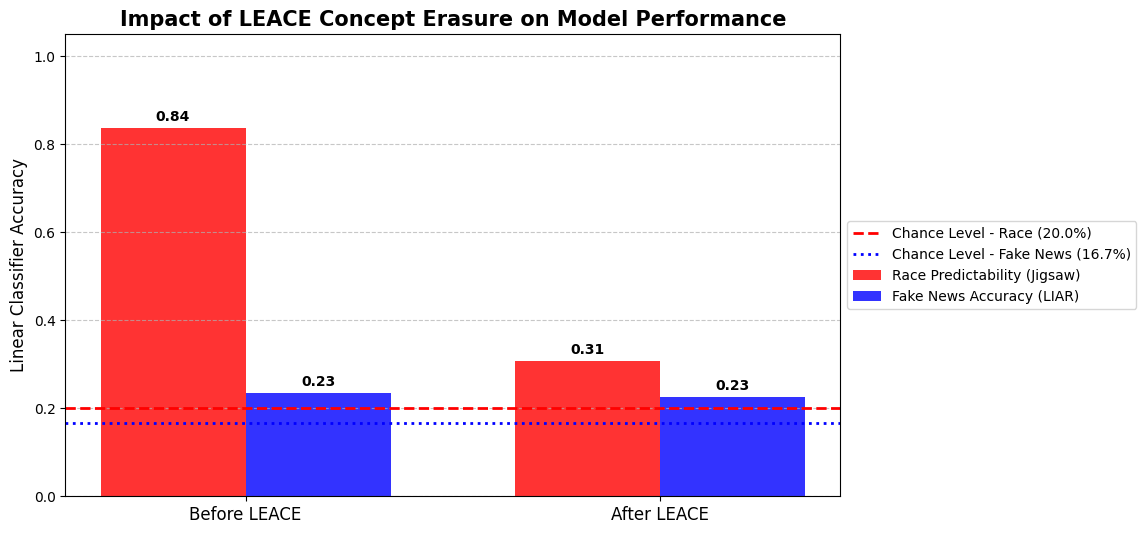

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import torch
from sklearn.linear_model import SGDClassifier

# =====================================================================
# 1. PRÉPARATION ET ÉVALUATION : AVANT / APRÈS LEACE
# =====================================================================
print("Évaluation des performances linéaires (Avant / Après LEACE)...")

# --- A. Niveau de hasard (Chance Level) ---
num_classes_jigsaw = len(np.unique(z_jigsaw))
hasard_jigsaw = 1.0 / num_classes_jigsaw

num_classes_liar = len(np.unique(y_train_liar))
hasard_liar = 1.0 / num_classes_liar

# --- B. Classifieurs Linéaires Standards ---
clf_jigsaw = SGDClassifier(loss='log_loss', max_iter=100, class_weight='balanced', tol=1e-3, n_jobs=-1)
clf_liar = SGDClassifier(loss='log_loss', max_iter=100, class_weight='balanced', tol=1e-3, n_jobs=-1)

# --- C. Évaluation AVANT LEACE ---
clf_jigsaw.fit(X_train_jigsaw, z_train_jigsaw)
acc_jigsaw_before = accuracy_score(z_dev_jigsaw, clf_jigsaw.predict(X_dev_jigsaw))

clf_liar.fit(X_train_liar, y_train_liar)
acc_liar_before = accuracy_score(y_test_liar, clf_liar.predict(X_test_liar))

# --- D. Application de LEACE sur les données de dev Jigsaw (pour tester) ---
X_train_jigsaw_leace = eraser(torch.from_numpy(X_train_jigsaw).float()).numpy()
X_dev_jigsaw_leace = eraser(torch.from_numpy(X_dev_jigsaw).float()).numpy()

# --- E. Évaluation APRÈS LEACE ---
clf_jigsaw.fit(X_train_jigsaw_leace, z_train_jigsaw)
acc_jigsaw_after = accuracy_score(z_dev_jigsaw, clf_jigsaw.predict(X_dev_jigsaw_leace))

clf_liar.fit(X_train_liar_debiased, y_train_liar) # X_train_liar_debiased vient de la cellule précédente
acc_liar_after = accuracy_score(y_test_liar, clf_liar.predict(X_test_liar_debiased))

# =====================================================================
# 2. AFFICHAGE DES VALEURS DANS UN TABLEAU TEXTUEL
# =====================================================================
print("\n" + "="*70)
print(f"{'State':<15} | {f'{nom_categorie} Accuracy':<22} | {'Fake News Accuracy':<22}")
print("="*70)
print(f"{'Before LEACE':<15} | {acc_jigsaw_before:<22.4f} | {acc_liar_before:<22.4f}")
print(f"{'After LEACE':<15} | {acc_jigsaw_after:<22.4f} | {acc_liar_after:<22.4f}")
print("="*70 + "\n")

# =====================================================================
# 3. TRACÉ DU DIAGRAMME À BARRES (EN ANGLAIS)
# =====================================================================
plt.figure(figsize=(10, 6))

# Paramètres des barres
labels = ['Before LEACE', 'After LEACE']
x = np.arange(len(labels))
width = 0.35

# Création des barres
rects1 = plt.bar(x - width/2, [acc_jigsaw_before, acc_jigsaw_after], width, 
                 label=f'{nom_categorie} Predictability (Jigsaw)', color='red', alpha=0.8)
rects2 = plt.bar(x + width/2, [acc_liar_before, acc_liar_after], width, 
                 label='Fake News Accuracy (LIAR)', color='blue', alpha=0.8)

# Lignes de hasard
plt.axhline(y=hasard_jigsaw, color='red', linestyle='--', linewidth=2, 
            label=f'Chance Level - {nom_categorie} ({hasard_jigsaw*100:.1f}%)')
plt.axhline(y=hasard_liar, color='blue', linestyle=':', linewidth=2, 
            label=f'Chance Level - Fake News ({hasard_liar*100:.1f}%)')

# Esthétique et Labels
plt.ylabel('Linear Classifier Accuracy', fontsize=12)
plt.title('Impact of LEACE Concept Erasure on Model Performance', fontsize=15, fontweight='bold')
plt.xticks(x, labels, fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajout des valeurs au-dessus des barres
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Décalage vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.savefig(f"{DOSSIER_ATTRIBUT}/LEACE_impact_bar_chart_{suffix}.png", dpi=300, bbox_inches='tight')
plt.show()

--- STEP 1: BEFORE LEACE ---
Calcul de la LDA pour 'BERT Space (LDA) - Before LEACE (Race)'...


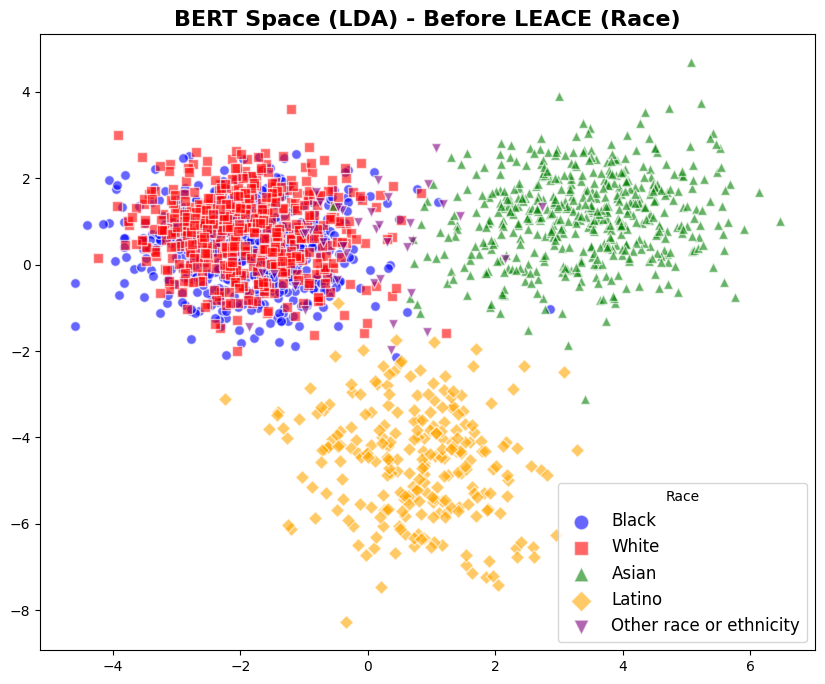


--- STEP 2: AFTER LEACE ---
Calcul de la LDA pour 'BERT Space (LDA) - After LEACE (Race)'...


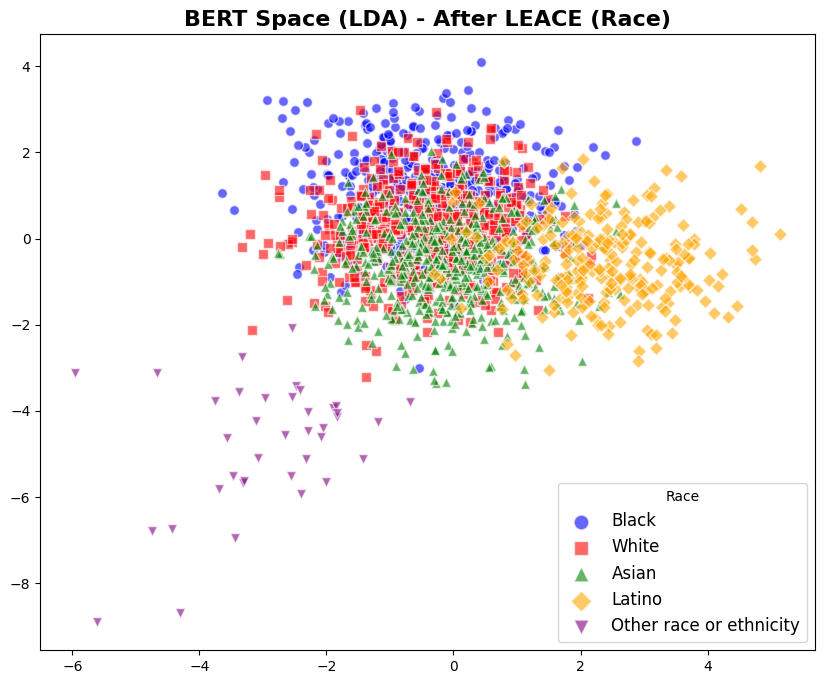

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import numpy as np
import torch # NOUVEAU : Requis pour passer les vecteurs à LEACE

# --- 1. CRÉATION DYNAMIQUE DU MAPPING ---
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

category_mapping = {}
for i, col in enumerate(target_cols):
    clean_name = col.replace('_', ' ').capitalize()
    category_mapping[i] = (clean_name, colors[i % len(colors)], markers[i % len(markers)])

# --- 2. FONCTION DE TRACÉ ---
def plot_lda_by_category(vecs, labels, title, mapping, legend_name="Category"):
    print(f"Calcul de la LDA pour '{title}'...")
    
    lda = LDA(n_components=2)
    vecs_2d = lda.fit_transform(vecs, labels)
    
    plt.figure(figsize=(10, 8))
    unique_labels = sorted(list(set(labels.tolist())))
    
    for label in unique_labels:
        if label in mapping:
            name, color, marker = mapping[label]
            idx = (labels == label)
            
            plt.scatter(vecs_2d[idx, 0], vecs_2d[idx, 1], 
                        c=color, label=name, alpha=0.6, marker=marker, edgecolors='w', s=50)
            
    plt.legend(title=legend_name, fontsize=12, loc="best", markerscale=1.5)
    plt.title(title, fontsize=16, fontweight='bold')
    
    filename = f"{DOSSIER_ATTRIBUT}/{title.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')          
    plt.show()

# --- 3. PRÉPARATION DE L'ÉCHANTILLON ---
n_per_class = 500
indices_equilibres = []
num_classes = len(target_cols) 

for label in range(num_classes):
    idx_class = np.where(z_dev_jigsaw == label)[0]
    if len(idx_class) > 0:
        choix = np.random.choice(idx_class, min(n_per_class, len(idx_class)), replace=False)
        indices_equilibres.extend(choix)

X_sample = X_dev_jigsaw[indices_equilibres]
z_sample = z_dev_jigsaw[indices_equilibres]

print("--- STEP 1: BEFORE LEACE ---")
plot_lda_by_category(
    X_sample, z_sample, 
    title=f"BERT Space (LDA) - Before LEACE ({nom_categorie})", 
    mapping=category_mapping, 
    legend_name=nom_categorie
)

# =====================================================================
# MODIFICATION LEACE : On utilise l'eraser au lieu de P_matrix
# =====================================================================
# 1. On convertit notre échantillon en Tenseur PyTorch
X_sample_t = torch.from_numpy(X_sample).float()

# 2. On applique l'effacement LEACE
X_sample_leace_t = eraser(X_sample_t)

# 3. On revient en NumPy pour la LDA et l'affichage
X_sample_debiased = X_sample_leace_t.numpy()
# =====================================================================

print("\n--- STEP 2: AFTER LEACE ---")
plot_lda_by_category(
    X_sample_debiased, z_sample, 
    title=f"BERT Space (LDA) - After LEACE ({nom_categorie})", 
    mapping=category_mapping, 
    legend_name=nom_categorie
)